In [2]:
import pandas as pd
import numpy as np
import pyreadstat

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')
sns.set_palette('pastel')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# h2006_2: 주거 위치
# h2006_5: 주거 면적
# h2006_6: 주택 가격
# h2006_8: 주택구입비용, 보증금 마련 경로
# h2009_12aq2: 주택 관련 자금(전세보증금 포함) - 부채 및 이자


In [48]:
df = pd.read_spss('data/Koweps_hpwc20_2025_beta1.sav')

df.head()

,h20_id,h20_ind,h20_sn,h20_merkey,h_new,h_new1,h20_cobf,p20_wsc,p20_wsl,p20_wgc,...,wc20_63,wc20_64,wc20_5aq4,wc20_5aq5,wc20_5aq6,h20_pers_income1,h20_pers_income2,h20_pers_income3,h20_pers_income4,h20_pers_income5
0,2.0,1.0,1.0,20101.0,0.0,0.0,NaN,0.270248,0.269086,1513.433983,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,3.0,1.0,1.0,30101.0,0.0,0.0,NaN,0.424537,0.400322,2377.476553,...,NaN,NaN,NaN,NaN,NaN,NaN,2423.0,NaN,0.0,NaN
2,4.0,1.0,1.0,40101.0,0.0,0.0,NaN,0.230720,0.216585,1292.070254,...,NaN,NaN,NaN,NaN,NaN,NaN,337.0,NaN,0.0,NaN
3,6.0,1.0,1.0,60101.0,0.0,0.0,NaN,0.541744,0.498132,3033.853323,...,1.0,3.0,2.0,2.0,3.0,2825.0,NaN,NaN,0.0,NaN
4,6.0,1.0,1.0,60101.0,0.0,0.0,NaN,0.852575,0.827786,4774.555169,...,1.0,5.0,1.0,5.0,4.0,NaN,2278.0,NaN,0.0,NaN


In [49]:
raw_df = df.copy()
df = df.rename(columns={
    'h2006_2': 'location',
    'h2006_5': 'size',
    'h2006_6': 'price',
    'h2006_8': 'how',
    'h2009_12aq2': 'loan'
})
df = df[['location', 'size', 'price', 'how', 'loan']]
df

,location,size,price,how,loan
0,3.0,92.0,100000.0,1.0,64.705882
1,3.0,56.0,500.0,1.0,NaN
2,3.0,73.0,40000.0,1.0,0.000000
3,3.0,92.0,80000.0,1.0,100.000000
4,3.0,92.0,80000.0,1.0,100.000000
...,...,...,...,...,...
14910,3.0,112.0,80000.0,1.0,100.000000
14911,3.0,112.0,80000.0,1.0,100.000000
14912,3.0,112.0,80000.0,1.0,100.000000
14913,3.0,99.0,25000.0,1.0,66.828676


In [50]:
df.head(5)

,location,size,price,how,loan
0,3.0,92.0,100000.0,1.0,64.705882
1,3.0,56.0,500.0,1.0,NaN
2,3.0,73.0,40000.0,1.0,0.000000
3,3.0,92.0,80000.0,1.0,100.000000
4,3.0,92.0,80000.0,1.0,100.000000


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14915 entries, 0 to 14914
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   location  14915 non-null  float64
 1   size      14915 non-null  float64
 2   price     13438 non-null  float64
 3   how       13438 non-null  float64
 4   loan      7774 non-null   float64
dtypes: float64(5)
memory usage: 582.7 KB


<Axes: >

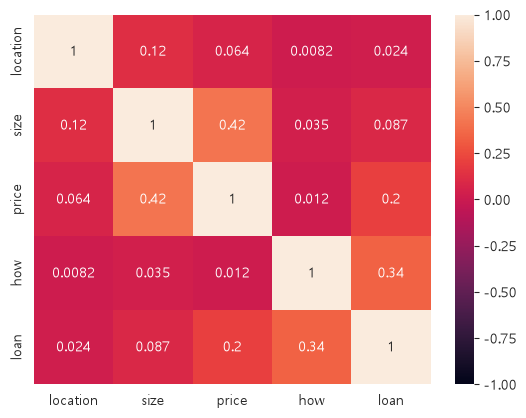

In [52]:
sns.heatmap(data=df.corr(), annot=True, vmin=-1, vmax=1)

In [53]:
# sns.countplot(df['location'])
# plt.show()

In [54]:
df = df.dropna()
df['location'] = np.where(
    df['location'] == 1.0, '지하층',
    np.where(df['location'] == 2.0, '반지하층',
             np.where(df['location'] == 3.0, '지상', '옥탑'))
)
df['size'] = df['size'].astype('int')
df['price'] = df['price'].astype('int')
df['how'] = np.where(
    df['how'] == 1.0, '자기돈',
    np.where(df['how'] == 2.0, '무상 도움',
             np.where(df['how'] == 3.0, '지인한테 빌림', 
                      np.where(df['how'] == 4.0, '금융기관', '사채')))
)

In [63]:
loc_price = df.groupby(['location'])['price'].mean()
loc_price

location
반지하층    10703.796296
지상      33047.593968
지하층       250.000000
Name: price, dtype: float64

<Axes: xlabel='location', ylabel='count'>

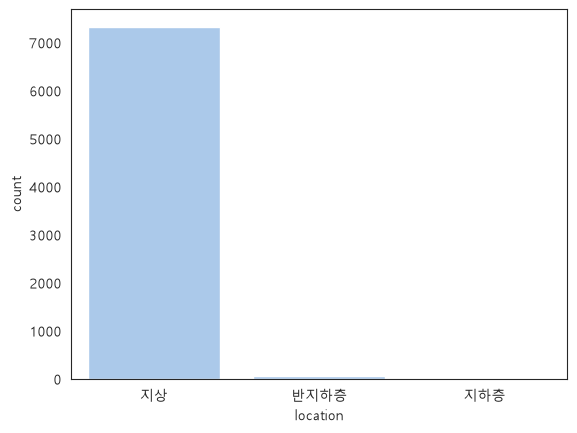

In [80]:
sns.countplot(x='location', data=df)

<Axes: xlabel='location', ylabel='price'>

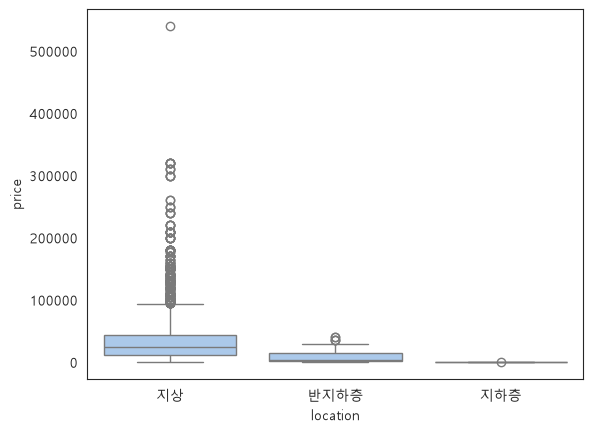

In [61]:
sns.boxplot(x='location', y='price', data=df)

<Axes: xlabel='size', ylabel='price'>

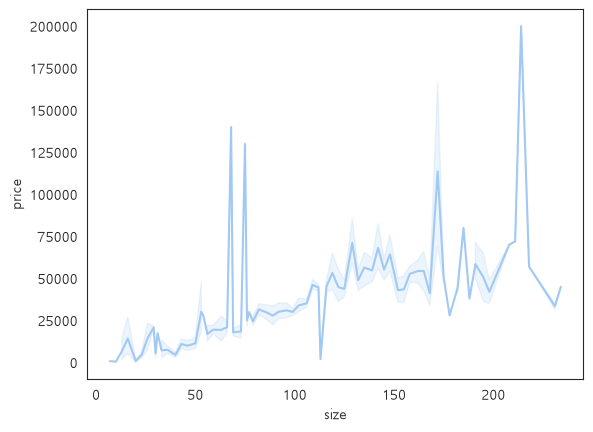

In [65]:
size_price = df.groupby(['size'])['price'].mean()
sns.lineplot(x='size', y='price', data=df)

<Axes: xlabel='how', ylabel='count'>

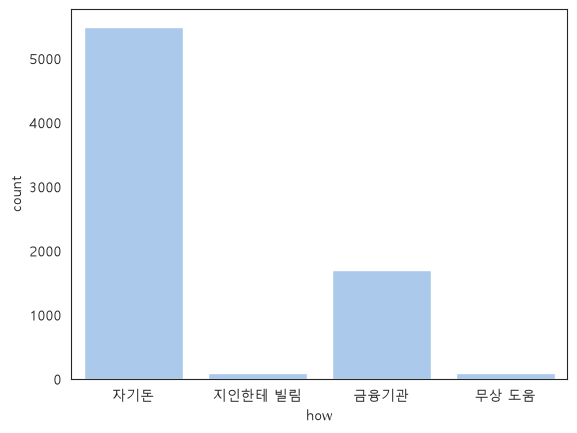

In [73]:
sns.countplot(x='how', data=df)

<Axes: xlabel='how', ylabel='loan'>

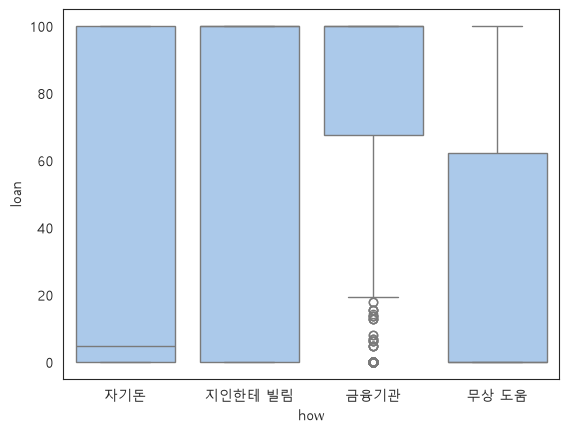

In [76]:
sns.boxplot(x='how', y='loan', data=df)

<Axes: xlabel='price', ylabel='loan'>

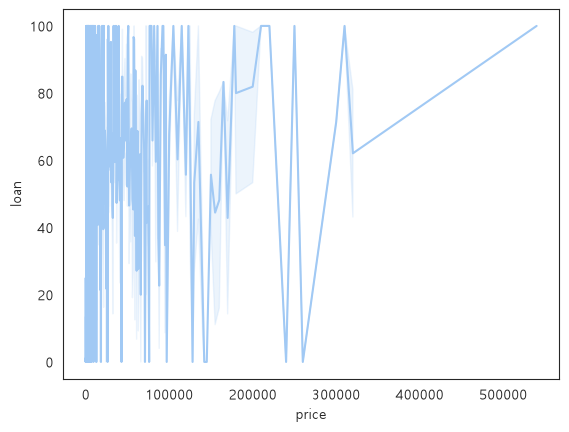

In [75]:
sns.lineplot(x='price', y='loan', data=df)

<Axes: xlabel='price', ylabel='Count'>

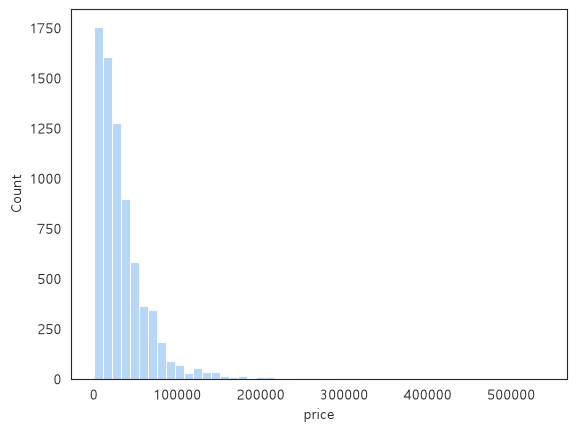

In [87]:
sns.histplot(x='price', data=df, bins=50)

<Axes: xlabel='loan', ylabel='size'>

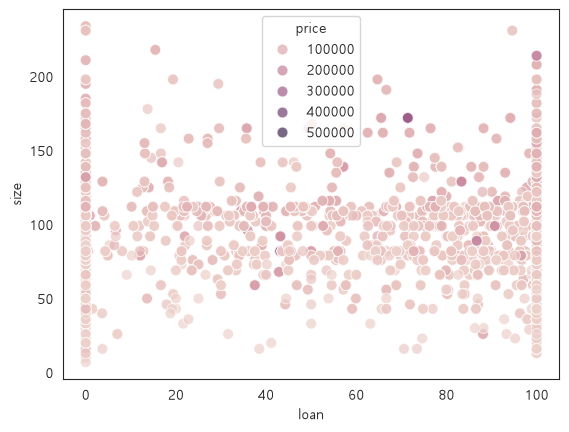

In [86]:
sns.scatterplot(
    data=df, 
    x='loan', 
    y='size', 
    hue='price',
    alpha=0.7,
    s=60
)